In [22]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat

In [23]:
# Each subjets electrode locations, registered to MNI space, in mm
aa_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy")
ap_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy")
ca_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy")
de_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy")
fp_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy")
ha_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy")
ja_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy")
jm_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy")
jt_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy")
mv_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy")
rn_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy")
rr_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/rr_xslocs_registered_mm.npy")
wc_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/wc_xslocs_registered_mm.npy")
zt_locs = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs/zt_xslocs_registered_mm.npy")

In [24]:
# All subjects' electrode locations in mni

all_electrodes = np.load("/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/all_electrodes_mni_locs.npy")


In [25]:
from pathlib import Path
import numpy as np
from scipy.io import loadmat
from scipy import signal, stats

project_root = Path('/Users/rustin/Documents/Big Data 567/SuperEeg-M467-project')
registered_dir = project_root / 'registered_outputs'
data_root = Path('/Users/rustin/Documents/Big Data 567/faces_basic/data')
out_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
out_dir.mkdir(parents=True, exist_ok=True)

srate = 1000  # Hz
sos_notch = signal.butter(4, [59.5, 60.5], btype='bandstop', fs=srate, output='sos')
kurtosis_thresh = 10  # drop channels with kurtosis >= 10 (same as SuperEEG paper)

print(f'Registered locs dir: {registered_dir}')
print(f'ECoG data dir:      {data_root}')
print(f'Per-subject output: {out_dir}')


Registered locs dir: /Users/rustin/Documents/Big Data 567/SuperEeg-M467-project/registered_outputs
ECoG data dir:      /Users/rustin/Documents/Big Data 567/faces_basic/data
Per-subject output: /Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed


In [26]:
from scipy.stats import kurtosis

for npy_file in sorted(registered_dir.glob('*_xslocs_registered_mm.npy')):
    pid = npy_file.stem.split('_')[0]
    locs = np.load(npy_file).astype(np.float32, copy=False)

    mat_path = data_root / pid / f'{pid}_faceshouses.mat'
    if not mat_path.exists():
        print(f'[{pid}] missing ECoG file: {mat_path}')
        continue

    mat = loadmat(mat_path, squeeze_me=True)
    ecog = np.asarray(mat['data'], dtype=np.float32)

    if ecog.ndim != 2:
        print(f'[{pid}] expected 2D ecog array, got shape {ecog.shape}; skipped')
        continue

    if ecog.shape[1] != locs.shape[0]:
        print(f'[{pid}] channel/loc mismatch: ecog channels={ecog.shape[1]} vs locs={locs.shape[0]}; skipped')
        continue

    stim = mat.get('stim')
    if stim is not None:
        stim = np.asarray(stim).ravel()
        if stim.shape[0] != ecog.shape[0]:
            print(f'[{pid}] stim length mismatch ({stim.shape[0]}) vs ecog rows ({ecog.shape[0]}); using all samples')
            ecog_nz = ecog
        else:
            mask = stim != 0
            ecog_nz = ecog[mask]
            if ecog_nz.shape[0] == 0:
                print(f'[{pid}] no non-zero stimulus samples; skipped')
                continue
    else:
        ecog_nz = ecog

    filtered_ecog = signal.sosfiltfilt(sos_notch, ecog_nz, axis=0).astype(np.float32, copy=False)

    k = kurtosis(filtered_ecog, axis=0, fisher=False, bias=False)
    good_idx = np.where(k <= kurtosis_thresh)[0]
    if good_idx.size < 2:
        print(f'[{pid}] only {good_idx.size} channels after kurtosis filter; skipped')
        continue

    cleaned_ecog = filtered_ecog[:, good_idx]
    cleaned_locs = locs[good_idx]

    out_path = out_dir / f'{pid}_preprocessed.npz'
    np.savez_compressed(
        out_path,
        subject_id=np.array(pid),
        sample_rate_hz=np.int32(srate),
        locs_mni_mm=cleaned_locs,
        ecog=cleaned_ecog,
    )

    dropped = locs.shape[0] - good_idx.size
    print(f'[{pid}] kept {good_idx.size}/{locs.shape[0]} channels (dropped {dropped} with kurtosis>{kurtosis_thresh})')
    print(f'[{pid}] wrote {out_path.name} | ecog={cleaned_ecog.shape}, locs={cleaned_locs.shape}')


[aa] kept 39/46 channels (dropped 7 with kurtosis>10)
[aa] wrote aa_preprocessed.npz | ecog=(244200, 39), locs=(39, 3)
[ap] kept 40/41 channels (dropped 1 with kurtosis>10)
[ap] wrote ap_preprocessed.npz | ecog=(241200, 40), locs=(40, 3)
[ca] kept 49/50 channels (dropped 1 with kurtosis>10)
[ca] wrote ca_preprocessed.npz | ecog=(244200, 49), locs=(49, 3)
[de] kept 31/31 channels (dropped 0 with kurtosis>10)
[de] wrote de_preprocessed.npz | ecog=(244200, 31), locs=(31, 3)
[fp] kept 50/52 channels (dropped 2 with kurtosis>10)
[fp] wrote fp_preprocessed.npz | ecog=(244200, 50), locs=(50, 3)
[ha] kept 38/39 channels (dropped 1 with kurtosis>10)
[ha] wrote ha_preprocessed.npz | ecog=(242200, 38), locs=(38, 3)
[ja] kept 54/60 channels (dropped 6 with kurtosis>10)
[ja] wrote ja_preprocessed.npz | ecog=(244200, 54), locs=(54, 3)
[jm] only 1 channels after kurtosis filter; skipped
[jt] kept 101/102 channels (dropped 1 with kurtosis>10)
[jt] wrote jt_preprocessed.npz | ecog=(244200, 101), locs=(

# Quick look at first subject (`*_preprocessed.npz`: locs + ecog, no stim file)

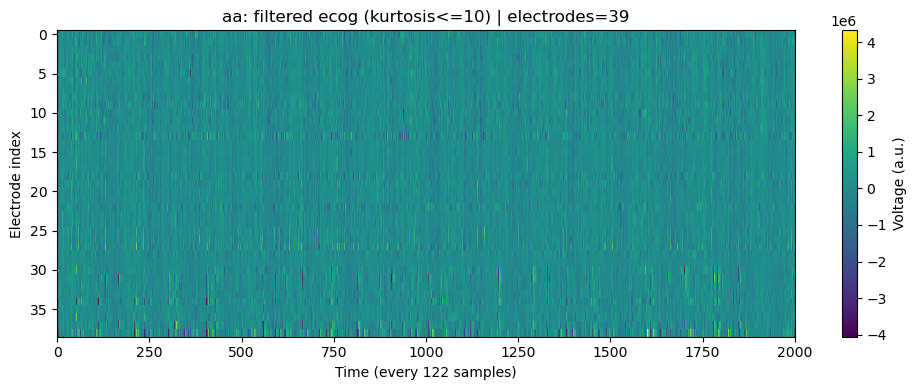

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

out_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
subject_files = sorted(out_dir.glob('*_preprocessed.npz'))
if not subject_files:
    raise FileNotFoundError('No *_preprocessed.npz files found in output dir')

first_path = subject_files[0]
pack = np.load(first_path, allow_pickle=True)
pid = str(pack['subject_id'].item())
ecog = pack['ecog']
locs = pack['locs_mni_mm']

step = max(1, ecog.shape[0] // 2000)
ecog_ds = ecog[::step]

plt.figure(figsize=(10, 4))
im = plt.imshow(ecog_ds.T, aspect='auto', cmap='viridis', interpolation='nearest')
plt.colorbar(im, label='Voltage (a.u.)')
plt.xlabel(f'Time (every {step} samples)')
plt.ylabel('Electrode index')
plt.title(f'{pid}: filtered ecog (kurtosis<={kurtosis_thresh}) | electrodes={locs.shape[0]}')
plt.tight_layout()
plt.show()


In [28]:
from pathlib import Path
import numpy as np

out_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
subject_files = sorted(out_dir.glob('*_preprocessed.npz'))
if not subject_files:
    raise FileNotFoundError('No *_preprocessed.npz files found in output dir')

path = subject_files[0]
pack = np.load(path, allow_pickle=True)

print(f'File: {path.name}')
print('Keys:', pack.files)
print('subject_id:', pack['subject_id'].item())
print('sample_rate_hz:', int(pack['sample_rate_hz']))
print('locs_mni_mm shape:', pack['locs_mni_mm'].shape)
print('ecog shape:', pack['ecog'].shape)


File: aa_preprocessed.npz
Keys: ['subject_id', 'sample_rate_hz', 'locs_mni_mm', 'ecog']
subject_id: aa
sample_rate_hz: 1000
locs_mni_mm shape: (39, 3)
ecog shape: (244200, 39)


# Optional: combine all per-subject `*_preprocessed.npz` files into one object array

In [29]:
# Run after per-subject files exist
from pathlib import Path
import numpy as np

out_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
records = []

for sub_path in sorted(out_dir.glob('*_preprocessed.npz')):
    pack = np.load(sub_path, allow_pickle=True)
    records.append({
        'patient_id': str(pack['subject_id'].item()),
        'sample_rate_hz': int(pack['sample_rate_hz']),
        'locs_mni_mm': pack['locs_mni_mm'],
        'ecog': pack['ecog'],
    })

combined_path = out_dir / 'all_locs_mni_and_ecog_preprocessed.npy'
np.save(combined_path, np.array(records, dtype=object))
print(f'Combined {len(records)} patients to {combined_path}')


Combined 13 patients to /Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed/all_locs_mni_and_ecog_preprocessed.npy


In [30]:
import numpy as np

path = "/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed/all_locs_mni_and_ecog_preprocessed.npy"
all_locs = np.load(path, allow_pickle=True)

print(all_locs.shape)
print(all_locs[0].keys())  # patient_id, sample_rate_hz, locs_mni_mm, ecog


(13,)
dict_keys(['patient_id', 'sample_rate_hz', 'locs_mni_mm', 'ecog'])


# Convert each per-subject preprocessed file to SuperEEG `file_io` input format

In [ ]:
from pathlib import Path
import numpy as np

preprocessed_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
npz_out_dir = Path('/Users/rustin/Documents/Big Data 567/Faces_Basic_npz_for_supereeg')
npz_out_dir.mkdir(parents=True, exist_ok=True)

for sub_path in sorted(preprocessed_dir.glob('*_preprocessed.npz')):
    pack = np.load(sub_path, allow_pickle=True)

    pid = str(pack['subject_id'].item())
    Y = pack['ecog']                                   # (time, channels)
    R = pack['locs_mni_mm']                            # (channels, 3) MNI mm
    samplerate   = np.array([int(pack['sample_rate_hz'])])  # 1-D, one value per session
    fname_labels = np.array([pid])                     # one session label

    out_path = npz_out_dir / f'{pid}.npz'
    np.savez(out_path, Y=Y, R=R, samplerate=samplerate, fname_labels=fname_labels)
    print(f'[{pid}] Y={Y.shape} R={R.shape} samplerate={samplerate} -> {out_path.name}')

print('Done.')
